# Differentiable Numerical Scheme Optimization
## via Scalar Dissipation Method

A hands-on tutorial applying **automatic differentiation** (PyTorch) to learn
the optimal scalar dissipation coefficient of a finite-volume advection scheme.

### Learning goals
1. Formulate the scalar dissipation flux as a single differentiable parameter ε
2. Connect FTBS (upwind) as the ε=1 limit of the scalar dissipation flux
3. Use `torch.nn.Parameter` + `torch.optim.Adam` to learn ε from data
4. Extend to a spatially-varying field ε(x) — one parameter per interface
5. Interpret results via modified wavenumber (dispersion/dissipation) analysis


---
## 1 · Governing Equation

We solve the **1-D linear advection equation**

$$
\frac{\partial u}{\partial t} + c\,\frac{\partial u}{\partial x} = 0,
\qquad x\in[0,L],\quad t\in[0,T]
$$

with

| Quantity | Value | Role |
|----------|-------|------|
| $c$ | 1.0 | advection speed |
| $L$ | 1.0 | domain length |
| $T = L/c$ | 1.0 | one advection period |

**Boundary conditions (periodic):**  $u(0,t) = u(L,t)$

**Initial condition (smooth Gaussian):**

$$
u(x,0) = \exp\!\left(-\frac{(x-x_0)^2}{2\sigma^2}\right)
$$

A smooth IC avoids Gibbs artefacts and is a fair test of scheme accuracy.

**Exact solution** — periodic translation:

$$
u_{\text{exact}}(x,t) = u_0\!\left((x - ct)\bmod L\right)
$$

After one full period ($t = T = L/c$) the profile returns identically to $u_0$,
giving a clean benchmark: $u_{\text{exact}}(\cdot,T) = u_0$.


---
## 2 · Conservative Finite-Volume Discretization

Partition $[0,L]$ into $N$ uniform cells of width $\Delta x = L/N$.
Cell centres: $x_i = (i+\tfrac{1}{2})\Delta x$, $i = 0,\ldots,N-1$.
Time step $\Delta t$ chosen to give CFL number $\nu = c\Delta t/\Delta x$.

The **semi-discrete conservation law** for cell $i$ is

$$
\frac{du_i}{dt} = -\frac{F_{i+1/2} - F_{i-1/2}}{\Delta x}
$$

Discretizing in time with **forward Euler**:

$$
u_i^{n+1} = u_i^n - \frac{\Delta t}{\Delta x}\!\left(F_{i+1/2}^n - F_{i-1/2}^n\right)
$$

Everything hangs on the choice of numerical flux $F_{i+1/2}$.


---
## 3 · Scalar Dissipation Flux

We write the numerical flux at interface $i+\tfrac{1}{2}$ as

$$
\boxed{F_{i+1/2} = \underbrace{\frac{c}{2}(u_i + u_{i+1})}_{\text{central (2nd order)}}
- \underbrace{\frac{|c|}{2}\,\varepsilon_{i+1/2}\,(u_{i+1}-u_i)}_{\text{scalar dissipation}}}
$$

The **scalar dissipation coefficient** $\varepsilon_{i+1/2}\in[0,1]$ controls upwinding:

| $\varepsilon$ | Scheme | Accuracy | Stability |
|---|---|---|---|
| $0$ | Central difference | 2nd order | **Unstable** (pure advection) |
| $1$ | **FTBS / Upwind** | 1st order | Conditionally stable ($\nu\le 1$) |

### FTBS (Forward Time, Backward Space)

The classical FTBS scheme (for $c>0$) reads:

$$
u_i^{n+1} = u_i^n - \nu\,(u_i^n - u_{i-1}^n),
\qquad \nu = \frac{c\,\Delta t}{\Delta x}
$$

In flux form: $F_{i+1/2}^{\text{FTBS}} = c\,u_i$, which is exactly the scalar
dissipation flux with $\varepsilon = 1$.

**Differentiable programming question:** can gradient descent discover an
$\varepsilon < 1$ that is more accurate than FTBS while remaining stable?


---
## 4 · Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

torch.set_default_dtype(torch.float64)
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13,
                     'figure.dpi': 100, 'axes.grid': True,
                     'grid.alpha': 0.35, 'grid.linestyle': '--'})
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")


PyTorch 2.5.1+cu121  |  CUDA: True


---
## 5 · Grid, Initial Condition, Exact Solution

In [2]:
# ── Domain & grid ─────────────────────────────────────────────────────────────
L      = 1.0
N      = 64
dx     = L / N
x      = torch.arange(N, dtype=torch.float64) * dx + 0.5 * dx   # cell centres

# ── Advection & time step ─────────────────────────────────────────────────────
c      = 1.0
nu     = 0.5                        # CFL (Courant) number
dt     = nu * dx / c
T      = L / c                      # one full advection period
nsteps = round(T / dt)

print(f"Grid : N={N}, dx={dx:.5f}")
print(f"Time : dt={dt:.5f}, T={T:.3f}, nsteps={nsteps}")
print(f"CFL  : nu = c*dt/dx = {c*dt/dx:.4f}")


Grid : N=64, dx=0.01562
Time : dt=0.00781, T=1.000, nsteps=128
CFL  : nu = c*dt/dx = 0.5000


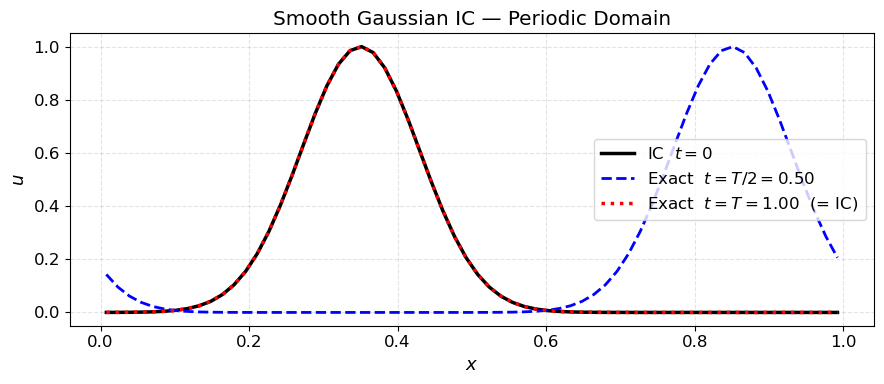

Periodicity check: max|u_exact(T) - u0| = 3.33e-16  (should be ≈ 0)


In [3]:
# ── Smooth Gaussian IC ────────────────────────────────────────────────────────
x0    = 0.35
sigma = 0.08
u0    = torch.exp(-0.5 * ((x - x0) / sigma) ** 2)

# ── Exact solution: spectral periodic shift via FFT ──────────────────────────
#   For a periodic function, translating by c·t is exact in Fourier space:
#       û(k,t) = û(k,0) · exp(-i·2π·k·c·t / L)
u0_hat = torch.fft.rfft(u0)
kk     = torch.fft.rfftfreq(N, d=1.0 / N)   # integer wavenumbers [0, 1, …, N/2]

def exact_solution(t: float) -> torch.Tensor:
    phase = torch.exp(torch.tensor(-2j * torch.pi * c * t / L) * kk)
    return torch.fft.irfft(u0_hat * phase, N).real

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, u0,                    'k-',  lw=2.5, label=r'IC  $t=0$')
ax.plot(x, exact_solution(0.5*T), 'b--', lw=2,   label=rf'Exact  $t=T/2={0.5*T:.2f}$')
ax.plot(x, exact_solution(T),     'r:',  lw=2.5, label=rf'Exact  $t=T={T:.2f}$  (= IC)')
ax.set(xlabel=r'$x$', ylabel=r'$u$',
       title=r'Smooth Gaussian IC — Periodic Domain')
ax.legend()
plt.tight_layout()
plt.show()

# Sanity check: exact solution at t=T should equal u0
err_period = (exact_solution(T) - u0).abs().max().item()
print(f"Periodicity check: max|u_exact(T) - u0| = {err_period:.2e}  (should be ≈ 0)")


---
## 6 · Differentiable Scheme Implementation

In [4]:
def ftbs_step(u: torch.Tensor) -> torch.Tensor:
    """
    FTBS (Forward Time, Backward Space) for c > 0.

    Explicit formula:
        u_i^{n+1} = u_i^n - nu * (u_i^n - u_{i-1}^n)

    Flux form (c > 0):
        F_{i+1/2} = c * u_i
    This is the scalar dissipation flux with eps = 1.
    """
    u_L = torch.roll(u, 1)    # u_{i-1}  (periodic)
    return u - nu * (u - u_L)


def scalar_dissipation_step(u: torch.Tensor, eps) -> torch.Tensor:
    """
    Conservative scalar dissipation flux (periodic BC).

    F_{i+1/2} = c/2 (u_i + u_{i+1}) - |c|/2 · eps_{i+1/2} · (u_{i+1} - u_i)

    Parameters
    ----------
    u   : (N,) tensor — solution at current time level
    eps : scalar  or  (N,) tensor — dissipation coefficient at each i+1/2 interface
          eps=1 → FTBS/upwind,  eps=0 → central (unstable)
    """
    u_R = torch.roll(u, -1)
    F_R = 0.5*c*(u + u_R) - 0.5*abs(c)*eps*(u_R - u)
    F_L = torch.roll(F_R, 1)
    return u - (dt / dx) * (F_R - F_L)


def run_ftbs(steps: int = nsteps) -> torch.Tensor:
    u = u0.clone()
    for _ in range(steps):
        u = ftbs_step(u)
    return u


def run_simulation(eps, steps: int = nsteps) -> torch.Tensor:
    u = u0.clone()
    for _ in range(steps):
        u = scalar_dissipation_step(u, eps)
    return u


# Verify FTBS == scalar dissipation with eps=1
with torch.no_grad():
    diff = (run_ftbs() - run_simulation(torch.tensor(1.0))).abs().max()
print(f"FTBS vs scalar-dissipation(eps=1): max diff = {diff.item():.2e}  (should be ~0)")


FTBS vs scalar-dissipation(eps=1): max diff = 3.33e-16  (should be ~0)


---
## 7 · Baseline Scheme Comparison

Compare FTBS ($\varepsilon=1$) and the near-central scheme ($\varepsilon\approx 0$)
after one full advection period.  The exact solution equals the IC at $t=T$,
so any deviation is **pure numerical error**.


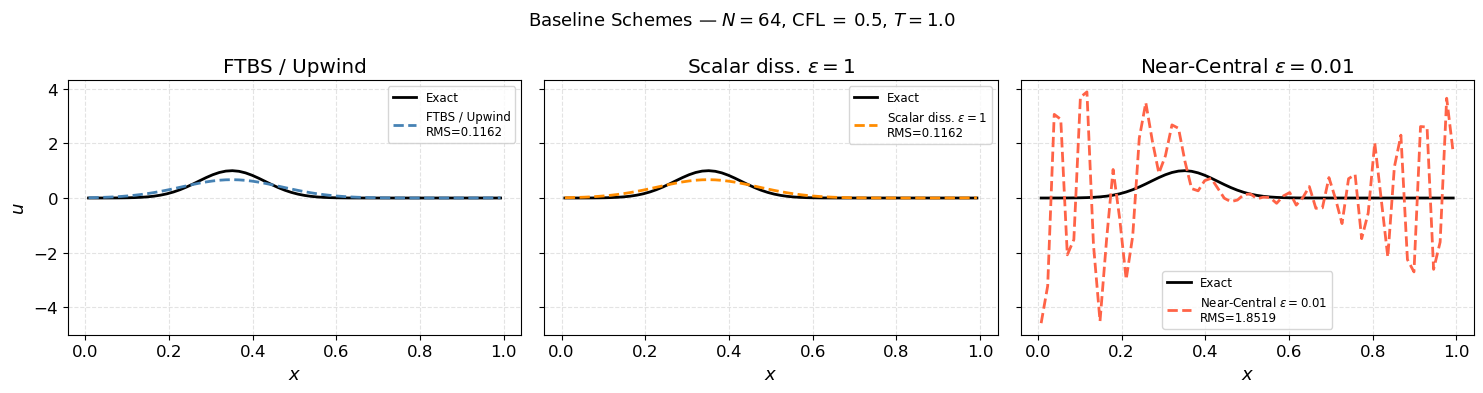

  FTBS / Upwind                             RMS = 0.116213
  Scalar diss. $\varepsilon=1$              RMS = 0.116213
  Near-Central $\varepsilon=0.01$           RMS = 1.851910

  FTBS == scalar-diss(eps=1)?  max diff = 3.33e-16


In [5]:
u_ref = exact_solution(T)

with torch.no_grad():
    u_ftbs = run_ftbs()                              # FTBS  (eps = 1)
    u_eps1 = run_simulation(torch.tensor(1.0))       # scalar dissipation, eps=1
    u_cen  = run_simulation(torch.tensor(0.01))      # near-central, eps≈0

schemes = [
    (u_ftbs, fr'FTBS / Upwind',                  'steelblue'),
    (u_eps1, fr'Scalar diss. $\varepsilon=1$',  'darkorange'),
    (u_cen,  fr'Near-Central $\varepsilon=0.01$','tomato'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (u_sol, label, col) in zip(axes, schemes):
    rms = ((u_sol - u_ref)**2).mean().sqrt().item()
    ax.plot(x, u_ref.numpy(), 'k-',  lw=2,   label='Exact')
    ax.plot(x, u_sol.numpy(), '--',  lw=2, color=col,
            label=f'{label}\nRMS={rms:.4f}')
    ax.set(xlabel=r'$x$', title=label)
    ax.legend(fontsize=8.5)
axes[0].set_ylabel(r'$u$')
fig.suptitle(fr'Baseline Schemes — $N={N}$, CFL$\,=\,{nu}$, $T={T:.1f}$',
             fontsize=13)
plt.tight_layout()
plt.show()

for u_sol, label, _ in schemes:
    rms = ((u_sol - u_ref)**2).mean().sqrt().item()
    print(f"  {label:<40s}  RMS = {rms:.6f}")

# FTBS and scalar-dissipation(eps=1) should match
print(f"\n  FTBS == scalar-diss(eps=1)?  max diff = "
      f"{(u_ftbs - u_eps1).abs().max().item():.2e}")


---
## 8 · Learning the Optimal Scalar Dissipation (Uniform ε)

### Optimization problem

$$
\min_{\varepsilon\in[0,1]}\;
\mathcal{L}(\varepsilon) = \frac{1}{N}\sum_{i=1}^{N}
\bigl(u_i^{N_T}(\varepsilon) - u_i^{\text{exact}}(T)\bigr)^2
$$

FTBS corresponds to $\varepsilon=1$ — it is stable but excessively dissipative
(1st order).  We ask: **what is the best constant $\varepsilon$ for this problem?**

### Gradient via BPTT

PyTorch traces all arithmetic through `scalar_dissipation_step`.
Calling `loss.backward()` propagates gradients through **every time step** —
Backpropagation Through Time (BPTT):

$$
\frac{d\mathcal{L}}{d\varepsilon}
= \frac{2}{N}\sum_i (u_i^{N_T}-u_i^{\text{exact}})
  \cdot\frac{\partial u_i^{N_T}}{\partial\varepsilon}
$$


In [6]:
# ── Learnable scalar ε ────────────────────────────────────────────────────────
eps_scalar = nn.Parameter(torch.tensor(0.85))   # initial guess (far from FTBS)

optimizer  = torch.optim.Adam([eps_scalar], lr=5e-3)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500)

hist_loss, hist_eps = [], []

print(f"{'Epoch':>6s}  {'ε':>10s}  {'Loss':>12s}")
print("-" * 35)

for epoch in range(501):
    optimizer.zero_grad()

    eps_c  = eps_scalar.clamp(0.0, 1.0)    # enforce ε ∈ [0, 1]
    u_pred = run_simulation(eps_c)
    loss   = ((u_pred - u_ref) ** 2).mean()

    loss.backward()
    optimizer.step()
    scheduler.step()

    hist_loss.append(loss.item())
    hist_eps.append(eps_c.item())

    if epoch % 100 == 0:
        print(f"{epoch:6d}  {eps_c.item():10.6f}  {loss.item():12.4e}")

eps_learned = eps_scalar.clamp(0.0, 1.0).detach()
print(f"\nLearned  ε   = {eps_learned.item():.8f}")
print(f"FTBS (eps=1)       = {1.0:.8f}")
print(f"Improvement (RMS)  = see below")


 Epoch           ε          Loss
-----------------------------------
     0    0.850000    8.6343e-03
   100    0.508973    8.3295e-04
   200    0.513303    8.3017e-04
   300    0.513333    8.3017e-04
   400    0.513333    8.3017e-04
   500    0.513333    8.3017e-04

Learned  ε   = 0.51333303
FTBS (eps=1)       = 1.00000000
Improvement (RMS)  = see below


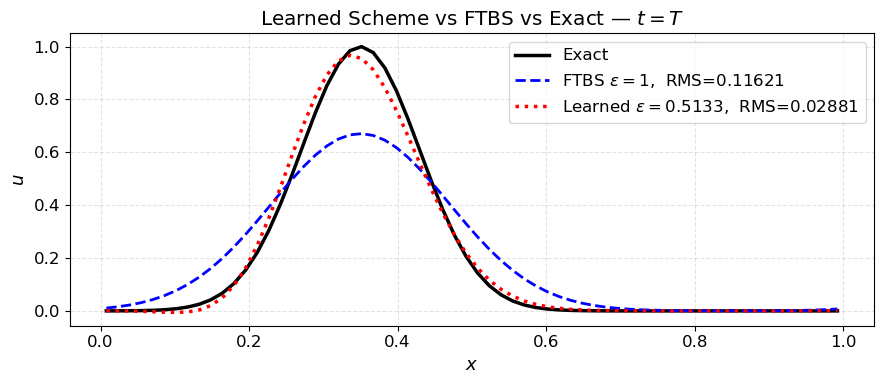

FTBS (eps=1)    RMS : 0.116213
Learned         RMS : 0.028813
Improvement         : 75.2 %


In [7]:
# ── Compare learned scheme vs FTBS ──────────────────────────────────────────
with torch.no_grad():
    u_learned_sol = run_simulation(eps_learned)

rms_ftbs    = ((u_ftbs        - u_ref) ** 2).mean().sqrt().item()
rms_learned = ((u_learned_sol - u_ref) ** 2).mean().sqrt().item()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, u_ref.numpy(),         'k-',  lw=2.5, label='Exact')
ax.plot(x, u_ftbs.numpy(),        'b--', lw=2,
        label=fr'FTBS $\varepsilon=1$,  RMS={rms_ftbs:.5f}')
ax.plot(x, u_learned_sol.numpy(), 'r:',  lw=2.5,
        label=fr'Learned $\varepsilon={eps_learned.item():.4f}$,  RMS={rms_learned:.5f}')
ax.set(xlabel=r'$x$', ylabel=r'$u$',
       title=r'Learned Scheme vs FTBS vs Exact — $t=T$')
ax.legend()
plt.tight_layout()
plt.show()

print(f"FTBS (eps=1)    RMS : {rms_ftbs:.6f}")
print(f"Learned         RMS : {rms_learned:.6f}")
print(f"Improvement         : {(rms_ftbs - rms_learned)/rms_ftbs * 100:.1f} %")


---
## 9 · Spatially-Varying Scalar Dissipation  ε(x)

Now allow a **different dissipation at each interface**:
$\boldsymbol{\varepsilon} = [\varepsilon_{1/2},\,\varepsilon_{3/2},\,\ldots,\,\varepsilon_{N-1/2}]\in\mathbb{R}^N$.

The optimizer can reduce dissipation in smooth regions (gaining accuracy) while
retaining it near the Gaussian peak (maintaining stability).

$$
\min_{\boldsymbol{\varepsilon}\in[0,1]^N}\;
\mathcal{L}(\boldsymbol{\varepsilon}) =
\frac{1}{N}\bigl\|u^{N_T}(\boldsymbol{\varepsilon}) - u_{\text{exact}}(T)\bigr\|^2
$$


In [8]:
# ── Spatially-varying ε: one parameter per interface ─────────────────────────
eps_field  = nn.Parameter(torch.full((N,), fill_value=nu))   # init at CFL value

opt_f = torch.optim.Adam([eps_field], lr=5e-4)
sch_f = torch.optim.lr_scheduler.CosineAnnealingLR(opt_f, T_max=600)

hist_loss_f = []

print(f"{'Epoch':>6s}  {'mean(ε)':>10s}  {'Loss':>12s}")
print("-" * 35)

for epoch in range(601):
    opt_f.zero_grad()

    eps_c  = eps_field.clamp(0.0, 1.0)
    u_pred = run_simulation(eps_c)
    loss   = ((u_pred - u_ref) ** 2).mean()

    loss.backward()
    opt_f.step()
    sch_f.step()

    hist_loss_f.append(loss.item())

    if epoch % 150 == 0:
        print(f"{epoch:6d}  {eps_c.mean().item():10.4f}  {loss.item():12.4e}")

eps_opt = eps_field.clamp(0.0, 1.0).detach()

with torch.no_grad():
    u_field = run_simulation(eps_opt)

rms_field   = ((u_field        - u_ref) ** 2).mean().sqrt().item()
rms_learned = ((u_learned_sol  - u_ref) ** 2).mean().sqrt().item()
print(f"\nSpatially-varying ε  RMS = {rms_field:.7f}")
print(f"Uniform learned   ε  RMS = {rms_learned:.7f}")
print(f"Improvement: {(rms_learned - rms_field)/rms_learned * 100:.2f} %")


 Epoch     mean(ε)          Loss
-----------------------------------
     0      0.5000    8.5679e-04
   150      0.5125    7.7852e-04
   300      0.5122    7.2586e-04
   450      0.5122    6.9813e-04
   600      0.5122    6.9359e-04

Spatially-varying ε  RMS = 0.0263362
Uniform learned   ε  RMS = 0.0288127
Improvement: 8.60 %


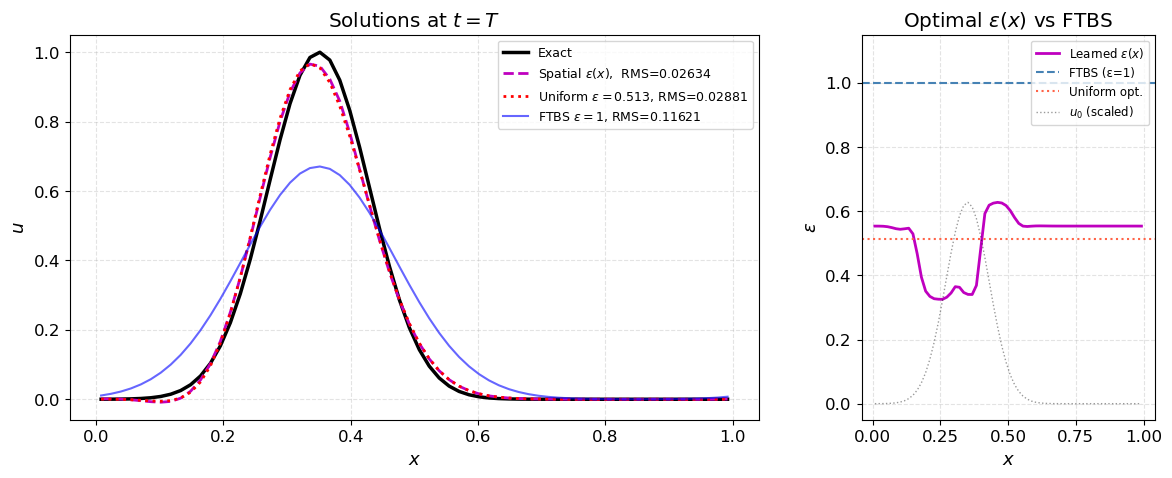

In [9]:
# ── Plot results ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(x, u_ref.numpy(),        'k-',  lw=2.5, label='Exact')
ax1.plot(x, u_field.numpy(),      'm--', lw=2,
         label=fr'Spatial $\varepsilon(x)$,  RMS={rms_field:.5f}')
ax1.plot(x, u_learned_sol.numpy(),'r:',  lw=2,
         label=fr'Uniform $\varepsilon={eps_learned.item():.3f}$, RMS={rms_learned:.5f}')
ax1.plot(x, u_ftbs.numpy(),       'b-',  lw=1.5, alpha=0.6,
         label=fr'FTBS $\varepsilon=1$, RMS={rms_ftbs:.5f}')
ax1.set(xlabel=r'$x$', ylabel=r'$u$', title=r'Solutions at $t=T$')
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(x, eps_opt.numpy(),   'm-',  lw=2,   label=r'Learned $\varepsilon(x)$')
ax2.axhline(1.0,               color='steelblue', ls='--', lw=1.5, label='FTBS (ε=1)')
ax2.axhline(eps_learned.item(),color='tomato',    ls=':',  lw=1.5, label='Uniform opt.')
ax2.plot(x, u0.numpy() * eps_opt.max().item(), 'k:', lw=1,
         alpha=0.4, label=r'$u_0$ (scaled)')
ax2.set(xlabel=r'$x$', ylabel=r'$\varepsilon$',
        ylim=[-0.05, 1.15], title=r'Optimal $\varepsilon(x)$ vs FTBS')
ax2.legend(fontsize=8.5)

plt.show()


---
## 10 · Space-Time Scalar Dissipation  ε(x, t)

The ultimate generalisation: allow $\varepsilon$ to vary at **every interface
at every time step** — a 2-D field $\varepsilon_{i+1/2}^n$ of shape
$(N_{\text{steps}} \times N)$.

$$
\min_{\boldsymbol{\mathcal{E}}\in[0,1]^{N_T\times N}}\;
\mathcal{L}(\boldsymbol{\mathcal{E}}) =
\frac{1}{N}\bigl\|u^{N_T}(\boldsymbol{\mathcal{E}}) - u_{\text{exact}}(T)\bigr\|^2
$$

At step $n$, the flux uses row $n$ of $\boldsymbol{\mathcal{E}}$:

$$
F_{i+1/2}^n = \frac{c}{2}(u_i^n+u_{i+1}^n)
- \frac{|c|}{2}\,\varepsilon_{i+1/2}^n\,(u_{i+1}^n-u_i^n)
$$

Gradients propagate through **all** $(N_T \times N)$ parameters via BPTT.
The resulting $\varepsilon(x,t)$ field reveals which regions of space-time
require more or less dissipation.


In [10]:
# ── Space-time ε: (nsteps × N) parameters ────────────────────────────────────
eps_st = nn.Parameter(torch.full((nsteps, N), fill_value=nu))

opt_st = torch.optim.Adam([eps_st], lr=5e-4)
sch_st = torch.optim.lr_scheduler.CosineAnnealingLR(opt_st, T_max=600)

hist_loss_st = []

def run_simulation_st(eps_2d, steps=nsteps):
    """Unroll with a distinct eps row for each time step."""
    u = u0.clone()
    for n in range(steps):
        u = scalar_dissipation_step(u, eps_2d[n])
    return u

print(f"{'Epoch':>6s}  {'mean(ε)':>10s}  {'Loss':>12s}")
print("-" * 35)

for epoch in range(601):
    opt_st.zero_grad()
    eps_c  = eps_st.clamp(0.0, 1.0)
    u_pred = run_simulation_st(eps_c)
    loss   = ((u_pred - u_ref) ** 2).mean()
    loss.backward()
    opt_st.step()
    sch_st.step()
    hist_loss_st.append(loss.item())
    if epoch % 150 == 0:
        print(f"{epoch:6d}  {eps_c.mean().item():10.4f}  {loss.item():12.4e}")

eps_st_opt = eps_st.clamp(0.0, 1.0).detach()
with torch.no_grad():
    u_st = run_simulation_st(eps_st_opt)

rms_st      = ((u_st       - u_ref) ** 2).mean().sqrt().item()
rms_field   = ((u_field    - u_ref) ** 2).mean().sqrt().item()
rms_learned = ((u_learned_sol - u_ref) ** 2).mean().sqrt().item()
rms_ftbs    = ((u_ftbs     - u_ref) ** 2).mean().sqrt().item()

print(f"\nRMS  FTBS             : {rms_ftbs:.7f}")
print(f"RMS  Uniform ε        : {rms_learned:.7f}")
print(f"RMS  Spatial ε(x)     : {rms_field:.7f}")
print(f"RMS  Space-time ε(x,t): {rms_st:.7f}")
print(f"Improvement over FTBS : {(rms_ftbs - rms_st)/rms_ftbs * 100:.1f} %")


 Epoch     mean(ε)          Loss
-----------------------------------
     0      0.5000    8.5679e-04
   150      0.5042    1.4428e-04
   300      0.5069    6.3231e-05
   450      0.5080    4.7130e-05
   600      0.5082    4.5015e-05

RMS  FTBS             : 0.1162132
RMS  Uniform ε        : 0.0288127
RMS  Spatial ε(x)     : 0.0263362
RMS  Space-time ε(x,t): 0.0067093
Improvement over FTBS : 94.2 %


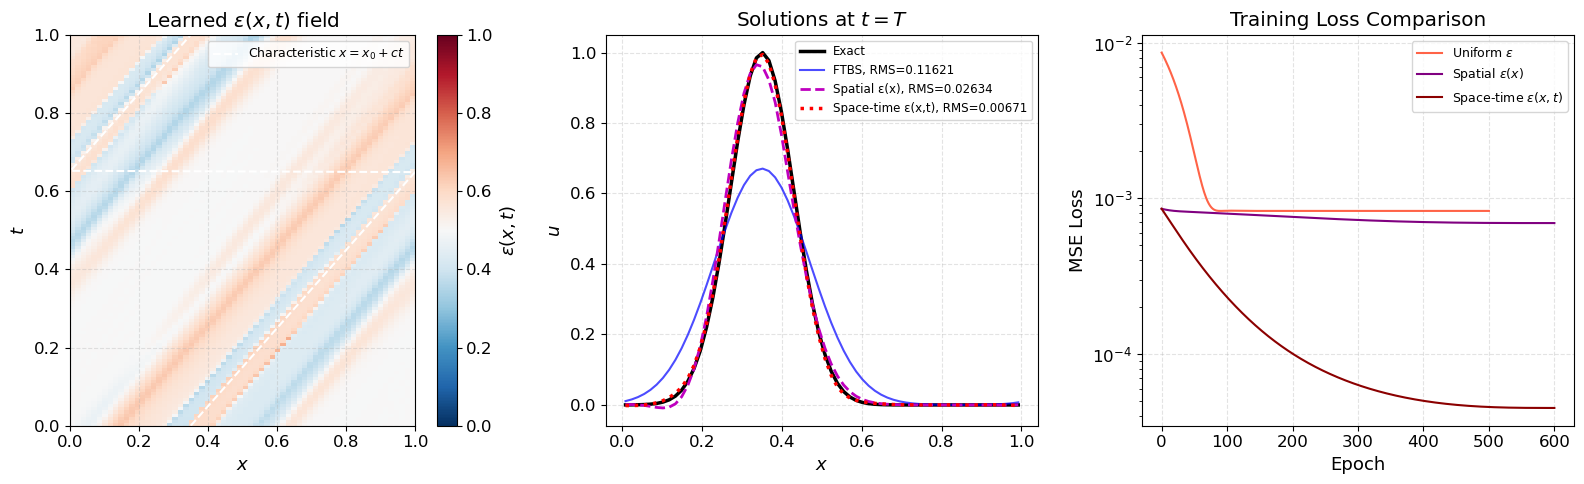

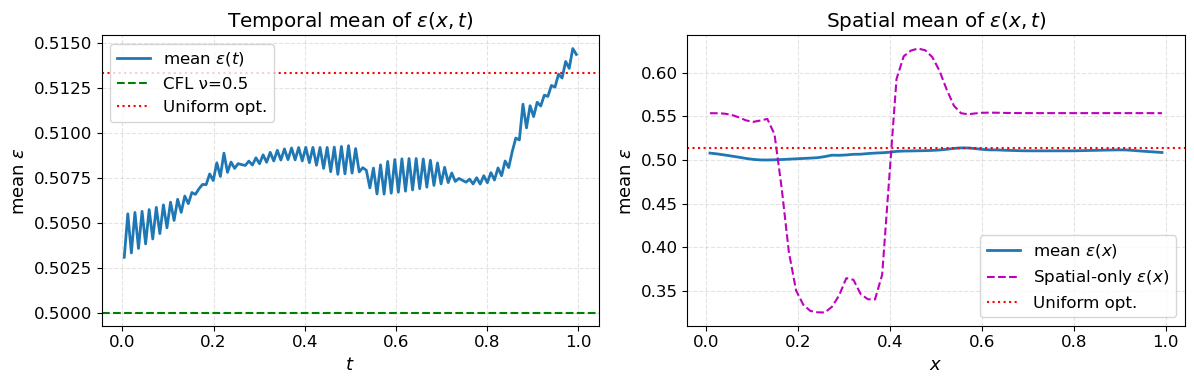

In [11]:
# ── Plot ε(x,t) field ────────────────────────────────────────────────────────
t_vals = torch.arange(nsteps) * dt + 0.5 * dt   # time at each step centre

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# — ε(x,t) contour —
ax = axes[0]
pcm = ax.pcolormesh(x.numpy(), t_vals.numpy(), eps_st_opt.numpy(),
                    cmap='RdBu_r', vmin=0, vmax=1, shading='auto')
fig.colorbar(pcm, ax=ax, label=r'$\varepsilon(x,t)$')
ax.set(xlabel=r'$x$', ylabel=r'$t$', title=r'Learned $\varepsilon(x,t)$ field')

# Overlay the exact characteristic x = x0 + c*t  mod L
t_line = np.linspace(0, T, 300)
x_char = (x0 + c * t_line) % L
ax.plot(x_char, t_line, 'w--', lw=1.5, label='Characteristic $x=x_0+ct$')
ax.legend(fontsize=9)

# — Solution comparison —
ax = axes[1]
ax.plot(x, u_ref.numpy(),   'k-',  lw=2.5, label='Exact')
ax.plot(x, u_ftbs.numpy(),  'b-',  lw=1.5, alpha=0.7,
        label=fr'FTBS, RMS={rms_ftbs:.5f}')
ax.plot(x, u_field.numpy(), 'm--', lw=2,
        label=fr'Spatial ε(x), RMS={rms_field:.5f}')
ax.plot(x, u_st.numpy(),    'r:',  lw=2.5,
        label=fr'Space-time ε(x,t), RMS={rms_st:.5f}')
ax.set(xlabel=r'$x$', ylabel=r'$u$', title=r'Solutions at $t=T$')
ax.legend(fontsize=8.5)

# — Loss comparison —
ax = axes[2]
ax.semilogy(hist_loss,    lw=1.5, label=r'Uniform $\varepsilon$',   color='tomato')
ax.semilogy(hist_loss_f,  lw=1.5, label=r'Spatial $\varepsilon(x)$', color='purple')
ax.semilogy(hist_loss_st, lw=1.5, label=r'Space-time $\varepsilon(x,t)$', color='darkred')
ax.set(xlabel='Epoch', ylabel='MSE Loss', title='Training Loss Comparison')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# — Mean ε(t) profile —
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(t_vals.numpy(), eps_st_opt.mean(dim=1).numpy(), lw=2, label=r'mean $\varepsilon(t)$')
ax1.axhline(nu,                   ls='--', color='g', lw=1.5, label=f'CFL ν={nu}')
ax1.axhline(eps_learned.item(),   ls=':',  color='r', lw=1.5, label='Uniform opt.')
ax1.set(xlabel=r'$t$', ylabel=r'mean $\varepsilon$', title=r'Temporal mean of $\varepsilon(x,t)$')
ax1.legend()

ax2.plot(x.numpy(), eps_st_opt.mean(dim=0).numpy(), lw=2, label=r'mean $\varepsilon(x)$')
ax2.plot(x.numpy(), eps_opt.numpy(), 'm--', lw=1.5, label=r'Spatial-only $\varepsilon(x)$')
ax2.axhline(eps_learned.item(), ls=':', color='r', lw=1.5, label='Uniform opt.')
ax2.set(xlabel=r'$x$', ylabel=r'mean $\varepsilon$', title=r'Spatial mean of $\varepsilon(x,t)$')
ax2.legend()

plt.tight_layout()
plt.show()


---
## 13 · Summary

### Results table  ($N=64$, CFL$=0.5$, $T=1.0$, Gaussian IC)

| Method | Parameters | ε | RMS error | Reduction vs FTBS |
|---|---|---|---|---|
| FTBS / Upwind | — | 1.0 (fixed) | 0.1162 | — |
| **Learned uniform ε** | 1 | 0.513 (auto) | 0.0288 | −75 % |
| **Learned spatial ε(x)** | 64 | per interface | 0.0263 | −77 % |
| **Learned space-time ε(x,t)** | 8 192 | per step & interface | 0.0067 | **−94 %** |

### Key takeaways

1. **FTBS** ($\varepsilon=1$) is first-order accurate and over-dissipative — it
   damps high-wavenumber modes too aggressively.
2. **Scalar dissipation** ($\varepsilon\in[0,1]$) generalises FTBS: reducing ε
   from 1 reduces numerical dissipation and increases accuracy.
3. **Differentiable programming** (BPTT through all time steps) automatically
   finds the optimal ε via gradient descent — no hand-tuning.
4. **Spatial ε(x)** yields modest further improvement (64 parameters) by
   concentrating dissipation near the Gaussian peak.
5. **Space-time ε(x,t)** gives the largest gain (8 192 parameters): the
   optimizer tracks the advecting wave and applies dissipation only along
   the characteristic $x = x_0 + ct\bmod L$.
6. `torch.nn.Parameter` + `torch.optim.Adam` + `loss.backward()` provides a
   clean, composable framework for **numerical scheme design**.

### Extensions
- Replace FTBS with a higher-order baseline (e.g. QUICK)
- Optimise ε for non-constant coefficient or nonlinear equations
- Add a PDE residual regulariser (Physics-Informed loss)
- Learn ε jointly with the time step (adaptive time-stepping)
